# Zipf's Law

In [2]:
with open("../data/processed/don_quixote.txt", "r", encoding="utf-8") as textfile:
    data = textfile.read().split()
#data = ["hello", "hello", "world"]  # This is a placeholder list containing the tokens

data_count = {}

for token in data:
    current_count = data_count.get(token, 0)
    data_count[token] = current_count + 1

In [3]:
import matplotlib.pyplot as plt
import numpy as np

import numpy as np

counts = np.array(list(data_count.values()))
counts = np.sort(counts)[::-1]
rank = np.arange(1, len(counts) + 1)


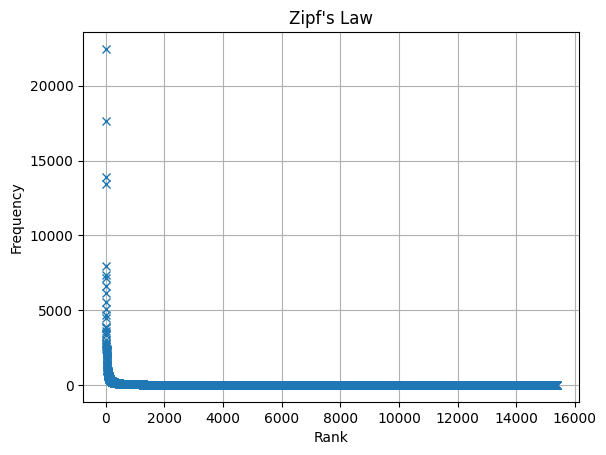

In [14]:
plt.plot(rank, counts, 'x')
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf's Law")
plt.grid()
#plt.savefig("Images/50_words.png", dpi=1000)
plt.show()

As these axis ranges skew the data such that the main pattern is not visible at first glance, we can limit the x-range to 0-150 to mitigate this.

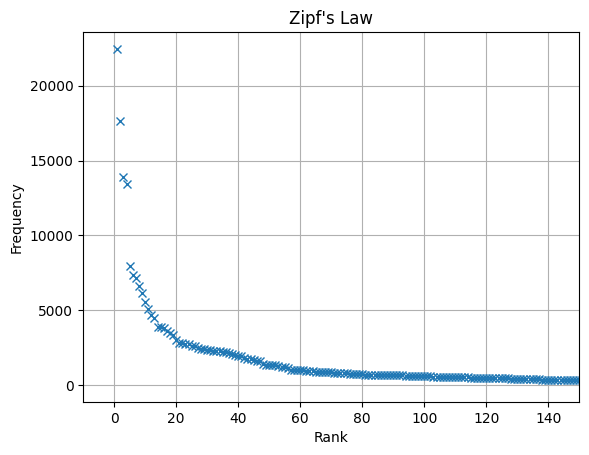

In [13]:
plt.plot(rank, counts, 'x')
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf's Law")
plt.xlim(-10, 150)
plt.grid()
#plt.savefig("Images/50_words.png", dpi=1000)
plt.show()

As per initial inspection, these results are as expected, we can proceed to log-log plot this graph to verify Zipf's law behaviour as:

$$
f(x) = \alpha x^\beta
$$

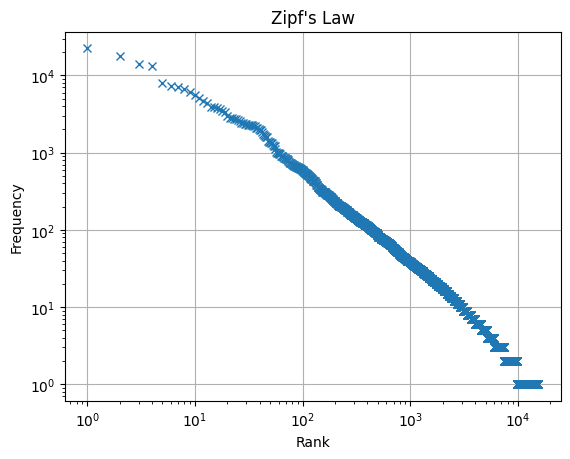

In [10]:
plt.loglog(rank, counts, 'x')
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf's Law")
plt.grid()
plt.show()

The above graph shows non-negligible straight-line behaviour. Therefore we can proceed with non-linear regression in a similar fashion to Heaps' law analysis to account for the non-normal residuals.

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(np.log(rank).reshape(-1, 1), np.log(counts).reshape(-1, 1))
beta_ols = model.coef_[0][0]
alpha_ols = np.exp(model.intercept_[0])
print(f"Fitted parameters: alpha = {alpha_ols:.4f}, beta = {beta_ols:.4f}")


from scipy.optimize import curve_fit

def zipf(x, alpha, beta):
    return alpha * x ** beta

(alpha, beta), pcov = curve_fit(zipf, rank, counts)
print(f"The zipf law results are: {alpha:.0f} ± {pcov[0][0]:.0f} * rank ^ ({beta:.2f} ± {pcov[1][1]:.2f})")

Fitted parameters: alpha = 521924.5546, beta = -1.3810
The zipf law results are: 27128 ± 4189 * rank ^ (-0.79 ± 0.00)


We can now visually inspect these results in a visual form as follows:

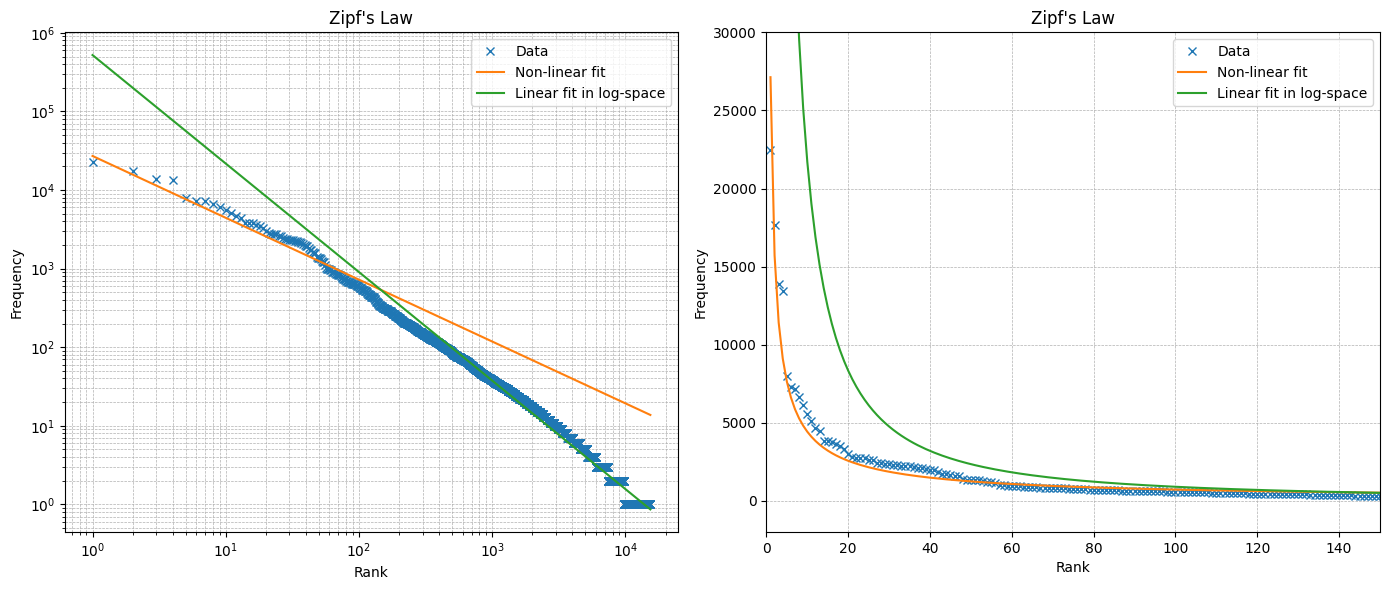

In [35]:

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].loglog(rank, counts, 'x', label="Data")
ax[0].plot(rank, alpha*rank**beta, label="Non-linear fit")
ax[0].plot(rank, alpha_ols*rank**beta_ols, label="Linear fit in log-space")
ax[0].set_xlabel("Rank")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Zipf's Law")
ax[0].grid(True, which="both", linestyle="--", linewidth=0.5)  
ax[0].legend()

ax[1].plot(rank, counts, 'x', label="Data")
ax[1].plot(rank, alpha*rank**beta, label="Non-linear fit")
ax[1].plot(rank, alpha_ols*rank**beta_ols, label="Linear fit in log-space")
ax[1].set_xlim(0, 150)
ax[1].set_ylim(-2000, 30000)
ax[1].set_xlabel("Rank")
ax[1].set_ylabel("Frequency")
ax[1].set_title("Zipf's Law")
ax[1].grid(True, which="both", linestyle="--", linewidth=0.5)  
ax[1].legend()

plt.tight_layout()
plt.show()

As we can see from the above, linear regression suffers from significant leverage issues due to many points having high ranks and low frequencies but the non-linear fit suffers from the opposite (although being more statistically rigurous. A hybrid approach (combining the two up until their respective intersections) may be considered.